# Ciencia de Datos en Producción — Entregable 3  
## comprension_eda.ipynb — Análisis Exploratorio (EDA)

Este notebook carga el CSV materializado en `Cargar_datos.ipynb` y realiza un **EDA experimental**.  
Aquí se realizan **gráficos, tablas y conclusiones accionables**.

**Target original:** `Pago_atiempo` (1 = paga a tiempo, 0 = mora)  
**Variable evento (para análisis):** `mora = 1 si Pago_atiempo == 0`

---

### **Importar Librerias**

In [111]:
from __future__ import annotations

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from scipy import stats
from pathlib import Path
from IPython.display import display

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 140)
pd.set_option("display.float_format", "{:,.4f}".format)

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (11, 4)


def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "mlops_pipeline").exists():
            return p
        p = p.parent
    return start.resolve()

---

### **Carga de datos**

In [112]:
here = Path.cwd()
repo_root = find_repo_root(here)

candidates = [
    repo_root / "mlops_pipeline" / "src" / "Base_de_datos.csv",
    here / "Base_de_datos.csv",
    repo_root / "Base_de_datos.csv",
]

csv_path = next((p for p in candidates if p.exists()), None)
if csv_path is None:
    raise FileNotFoundError(
        "No encontré Base_de_datos.csv.\n"
        "Ejecuta primero Cargar_datos.ipynb o verifica la ruta."
    )

df = pd.read_csv(csv_path)
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], dayfirst=False, errors="coerce")
df["mora"] = (df["Pago_atiempo"] == 0).astype(int)

print("✅ CSV cargado:", csv_path)
print("Shape:", df.shape)
df.head()

✅ CSV cargado: /Users/lamacravilla/Desktop/UPB/2026-1/CDP/mlops_pipeline/src/Base_de_datos.csv
Shape: (10763, 24)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo,mora
0,4,2025-01-07 14:40:36,"1,852,560.0000",12,32,Empleado,3500000,1000000,128650,95.2278,795.0000,0,2,0.0000,0.0000,NaN,NaN,0,0,0,"916,148.0000",Creciente,1,0
1,4,2025-01-09 11:18:48,"3,181,080.0000",6,34,Empleado,5000000,2000000,441817,95.2278,796.0000,0,7,0.0000,0.0000,NaN,NaN,0,0,0,"4,473,774.0000",Creciente,1,0
2,9,2024-12-26 18:52:57,"670,200.0000",5,34,Independiente,5000000,2000000,108632,95.2278,727.0000,5,0,0.0000,"274,561.0000","274,561.0000",NaN,2,0,1,NaN,NaN,1,0
3,9,2024-12-04 14:20:50,"506,806.8000",2,25,Independiente,3000000,900000,199684,95.2278,864.0000,8,1,0.0000,"27,564.0000","27,564.0000",NaN,1,0,6,NaN,NaN,1,0
4,4,2025-04-30 18:41:57,"999,780.0000",10,26,Empleado,2000000,600000,92509,95.2278,771.0000,0,3,0.0000,0.0000,NaN,NaN,0,0,0,"61,000.0000",Creciente,1,0


---

### **Descripción General del DataFrame**

In [113]:
# Tipos de datos y resumen
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 10763 entries, 0 to 10762
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   tipo_credito                   10763 non-null  int64         
 1   fecha_prestamo                 10763 non-null  datetime64[us]
 2   capital_prestado               10763 non-null  float64       
 3   plazo_meses                    10763 non-null  int64         
 4   edad_cliente                   10763 non-null  int64         
 5   tipo_laboral                   10763 non-null  str           
 6   salario_cliente                10763 non-null  int64         
 7   total_otros_prestamos          10763 non-null  int64         
 8   cuota_pactada                  10763 non-null  int64         
 9   puntaje                        10763 non-null  float64       
 10  puntaje_datacredito            10757 non-null  float64       
 11  cant_creditosvigentes     

,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,puntaje_datacredito,cant_creditosvigentes,huella_consulta,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,Pago_atiempo,mora
count,"10,763.0000",10763,"10,763.0000","10,763.0000","10,763.0000","10,763.0000","10,763.0000","10,763.0000","10,763.0000","10,757.0000","10,763.0000","10,763.0000","10,607.0000","10,607.0000","10,358.0000","10,173.0000","10,763.0000","10,763.0000","10,763.0000","7,833.0000","10,763.0000","10,763.0000"
mean,5.4111,2025-04-16 23:06:02.111121,"2,434,315.0013",10.5756,43.9486,"17,216,431.4599","6,238,869.6485","243,617.4067",91.1700,780.7908,5.7267,4.2286,7.7460,"45,937.4081","40,346.1682",0.2600,2.7800,0.2698,1.3027,"2,005,156.8118",0.9525,0.0475
min,4.0000,2024-11-26 09:17:04,"360,000.0000",2.0000,19.0000,0.0000,0.0000,"23,944.0000",-38.0100,-7.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,4.0000,2025-01-20 17:33:07.500000,"1,224,831.0000",6.0000,33.0000,"2,000,000.0000","500,000.0000","121,041.5000",95.2278,757.0000,3.0000,2.0000,0.0000,"2,898.0000","2,690.0000",0.0000,1.0000,0.0000,0.0000,"925,157.0000",1.0000,0.0000
50%,4.0000,2025-03-27 16:23:12,"1,921,920.0000",10.0000,42.0000,"3,000,000.0000","1,000,000.0000","182,863.0000",95.2278,791.0000,5.0000,4.0000,0.0000,"16,178.0000","14,442.5000",0.0000,2.0000,0.0000,1.0000,"1,204,496.0000",1.0000,0.0000
75%,9.0000,2025-06-16 13:27:58,"3,084,840.0000",12.0000,53.0000,"4,875,808.0000","2,000,000.0000","287,833.5000",95.2278,825.0000,8.0000,6.0000,0.0000,"52,982.0000","47,632.2500",0.0000,4.0000,0.0000,2.0000,"2,231,859.0000",1.0000,0.0000
max,68.0000,2026-04-26 18:43:52,"41,444,152.8000",90.0000,123.0000,"22,000,000,000.0000","6,787,675,263.0000","3,816,752.0000",95.2278,999.0000,62.0000,29.0000,"12,534.0000","5,116,066.0000","1,562,285.0000","2,145.0000",51.0000,13.0000,25.0000,"38,106,581.0000",1.0000,1.0000
std,2.3383,NaN,"1,909,642.7590",6.6321,15.0609,"355,476,717.6035","118,418,316.9411","210,493.6946",16.4654,104.8780,3.9772,3.0647,225.9551,"106,269.7899","71,242.4403",21.7729,2.7488,0.7165,1.8244,"2,144,116.1503",0.2127,0.2127


---

### **Calidad de Datos**

Registros duplicados: 0 de 10,763 (0.00%)


,Nulos,% Missing,Dtype
tendencia_ingresos,2932,27.2400,str
promedio_ingresos_datacredito,2930,27.2200,float64
saldo_mora_codeudor,590,5.4800,float64
saldo_principal,405,3.7600,float64
saldo_mora,156,1.4500,float64
saldo_total,156,1.4500,float64
puntaje_datacredito,6,0.0600,float64


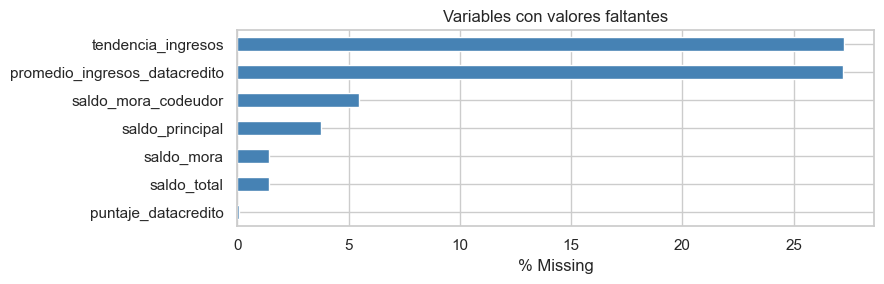

Valores categóricos válidos : 7,773
Valores numéricos (sucios)  : 58
Nulos                       : 2,932

Muestra de valores inválidos:


tendencia_ingresos
0          7
8315       6
1000000    4
9147       2
158042     1
3978       1
168750     1
-28589     1
-566272    1
24702      1
Name: count, dtype: int64

In [114]:
# Duplicados
dup = df.duplicated().sum()
print(f"Registros duplicados: {dup} de {len(df):,} ({dup/len(df)*100:.2f}%)")

# Nulos
missing = pd.DataFrame({
    "Nulos": df.isna().sum(),
    "% Missing": (df.isna().mean() * 100).round(2),
    "Dtype": df.dtypes
}).sort_values("% Missing", ascending=False)

display(missing[missing["Nulos"] > 0])

# Gráfico barras horizontales para nulos
mis_plot = missing[missing["Nulos"] > 0]["% Missing"]
if not mis_plot.empty:
    fig, ax = plt.subplots(figsize=(9, 3))
    mis_plot[::-1].plot(kind="barh", ax=ax, color="steelblue")
    ax.set_xlabel("% Missing")
    ax.set_title("Variables con valores faltantes")
    plt.tight_layout()
    plt.show()

# Problemas de calidad
valid_cat = {"Creciente", "Estable", "Decreciente"}
ti = df["tendencia_ingresos"]

n_valid = ti.isin(valid_cat).sum()
n_dirty = ti.notna().sum() - n_valid
n_null  = ti.isna().sum()

print(f"Valores categóricos válidos : {n_valid:,}")
print(f"Valores numéricos (sucios)  : {n_dirty:,}")
print(f"Nulos                       : {n_null:,}")
print()
print("Muestra de valores inválidos:")
display(ti[~ti.isin(valid_cat) & ti.notna()].value_counts().head(10))

---

### **Distribución del Target**

,conteo
Pago_atiempo,
1,10252
0,511


Tasa global de mora: 4.75%
  ⚠️ Dataset fuertemente desbalanceado (511 mora vs 10,252 al día)


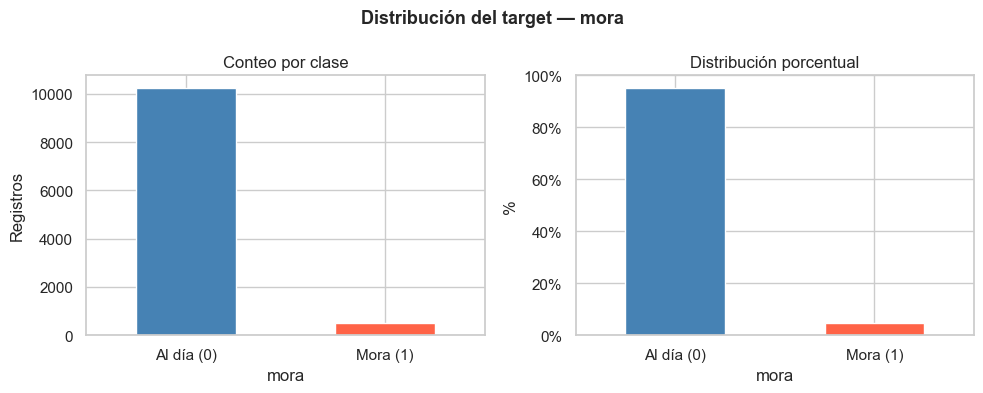

In [115]:
TARGET = "Pago_atiempo"
tasa_mora = df["mora"].mean()

display(df[TARGET].value_counts(dropna=False).rename("conteo").to_frame())
print(f"Tasa global de mora: {tasa_mora:.2%}")
print(f"  ⚠️ Dataset fuertemente desbalanceado ({df["mora"].sum():,} mora vs {(df["mora"]==0).sum():,} al día)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Conteos
df["mora"].value_counts().plot(kind="bar", ax=axes[0], color=["steelblue", "tomato"], edgecolor="white")
axes[0].set_xticklabels(["Al día (0)", "Mora (1)"], rotation=0)
axes[0].set_title("Conteo por clase")
axes[0].set_ylabel("Registros")

# Porcentaje
df["mora"].value_counts(normalize=True).mul(100).plot(
    kind="bar", ax=axes[1], color=["steelblue", "tomato"], edgecolor="white")
axes[1].set_xticklabels(["Al día (0)", "Mora (1)"], rotation=0)
axes[1].set_title("Distribución porcentual")
axes[1].set_ylabel("%")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())

plt.suptitle("Distribución del target — mora", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

---

### **Leakage**

Columnas tipo saldo (leakage directo): ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor']
--- Análisis de 'puntaje' ---


,count,mean,std,min,25%,50%,75%,max
mora,,,,,,,,
0,"10,252.0000",94.5634,2.8738,63.8097,95.2278,95.2278,95.2278,95.2278
1,511.0000,23.0912,26.0709,-38.0100,-3.5917,25.4195,47.6139,62.6676



Proporción de clientes al día con puntaje == máximo (95.23): 0.9176


/var/folders/6t/nkgjlt556_5016j78j0rpmnm0000gn/T/ipykernel_91000/2649782854.py:22: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/6t/nkgjlt556_5016j78j0rpmnm0000gn/T/ipykernel_91000/2649782854.py:22: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  plt.tight_layout()
/Users/lamacravilla/Desktop/UPB/2026-1/CDP/mlops_pipeline/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9888 (\N{WARNING SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/lamacravilla/Desktop/UPB/2026-1/CDP/mlops_pipeline/.venv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


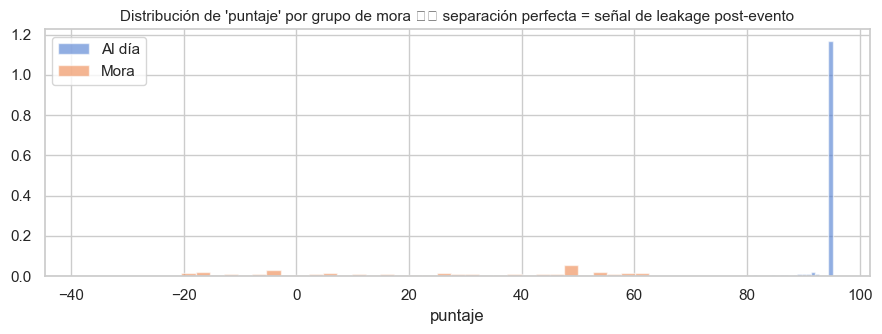

Columnas a EXCLUIR en ft_engineering.py: ['saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'puntaje']


In [116]:
# (variables de saldos suelen ser posteriores al evento)

# Leakage por nombre (saldos)
saldo_cols = [c for c in df.columns if c.lower().startswith("saldo")]
print("Columnas tipo saldo (leakage directo):", saldo_cols)

# Inspeccionar 'puntaje' — aparenta ser score post-evento
print("--- Análisis de 'puntaje' ---")
display(df.groupby("mora")["puntaje"].describe())
print()
print("Proporción de clientes al día con puntaje == máximo (95.23):",
      (df[df["mora"]==0]["puntaje"] == df["puntaje"].max()).mean().round(4))

fig, ax = plt.subplots(figsize=(9, 3.5))
for label, grp in df.groupby("mora")["puntaje"]:
    name = "Mora" if label == 1 else "Al día"
    ax.hist(grp.dropna(), bins=40, alpha=0.6, label=name, density=True)
ax.set_title("Distribución de 'puntaje' por grupo de mora"
                " ⚠️ separación perfecta = señal de leakage post-evento", fontsize=11)
ax.set_xlabel("puntaje")
ax.legend()
plt.tight_layout()
plt.show()

# Conclusión
leakage_cols = saldo_cols + ["puntaje"]
print(f"Columnas a EXCLUIR en ft_engineering.py: {leakage_cols}")

---

### **Análisis Temporal**

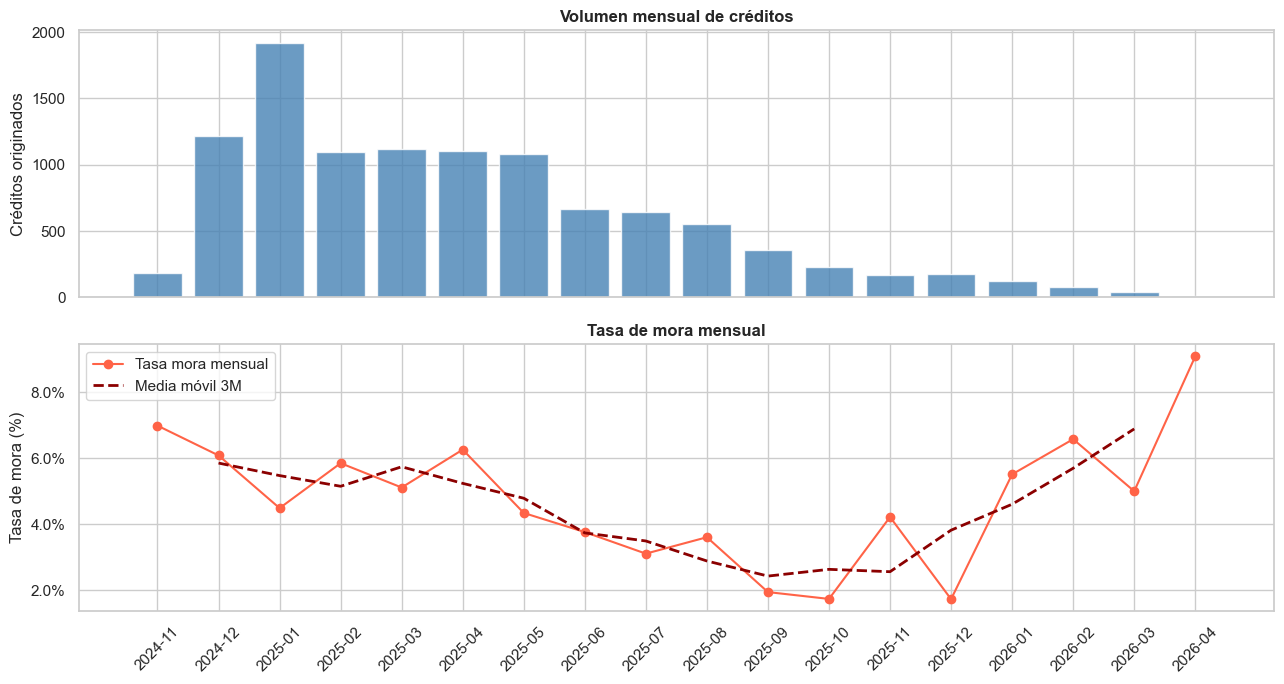

,Mes,Créditos,Tasa mora
0,2024-11,186,0.0699
1,2024-12,1216,0.0609
2,2025-01,1917,0.0449
3,2025-02,1094,0.0585
4,2025-03,1115,0.0511
5,2025-04,1102,0.0626
6,2025-05,1083,0.0434
7,2025-06,665,0.0376
8,2025-07,644,0.0311
9,2025-08,555,0.0360


In [118]:
# Garantizar tipo datetime
df["fecha_prestamo"] = pd.to_datetime(df["fecha_prestamo"], errors="coerce")

df["ym"] = df["fecha_prestamo"].dt.to_period("M")

monthly = (
    df.groupby("ym")
      .agg(n=("mora", "size"), mora_rate=("mora", "mean"))
      .reset_index()
)
monthly["ym_str"] = monthly["ym"].astype(str)

# Rolling media móvil 3 meses
monthly["mora_rolling3"] = monthly["mora_rate"].rolling(3, center=True).mean()

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# Volumen mensual
axes[0].bar(monthly["ym_str"], monthly["n"], color="steelblue", alpha=0.8)
axes[0].set_ylabel("Créditos originados")
axes[0].set_title("Volumen mensual de créditos", fontweight="bold")

# Tasa de mora mensual
axes[1].plot(monthly["ym_str"], monthly["mora_rate"] * 100,
             marker="o", color="tomato", label="Tasa mora mensual")
axes[1].plot(monthly["ym_str"], monthly["mora_rolling3"] * 100,
             linestyle="--", color="darkred", linewidth=2, label="Media móvil 3M")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_ylabel("Tasa de mora (%)")
axes[1].set_title("Tasa de mora mensual", fontweight="bold")
axes[1].legend()

for ax in axes:
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

display(monthly[["ym_str", "n", "mora_rate"]].rename(
    columns={"ym_str": "Mes", "n": "Créditos", "mora_rate": "Tasa mora"}))

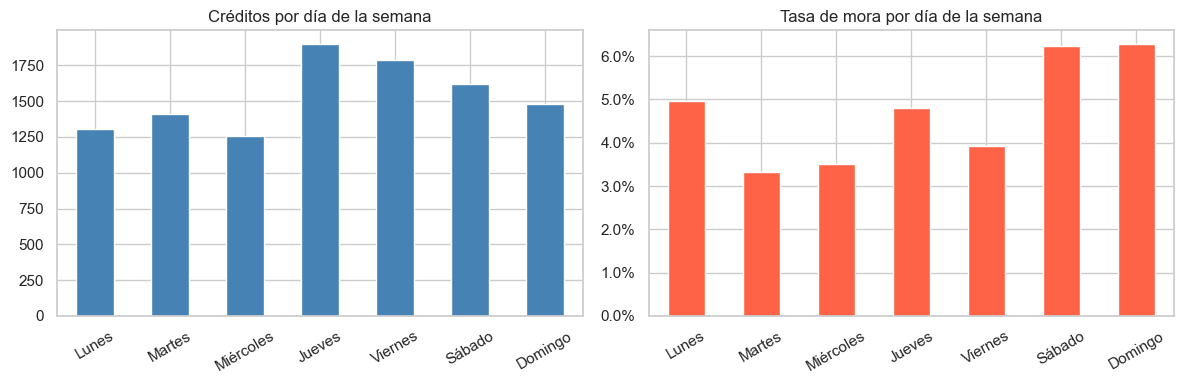

In [119]:
# Análisis por día de la semana
df["dia_semana"] = df["fecha_prestamo"].dt.day_name()
dias_orden = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
dias_es    = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]

dow = (
    df.groupby("dia_semana", observed=True)
      .agg(n=("mora", "size"), mora_rate=("mora", "mean"))
      .reindex(dias_orden)
)
dow.index = dias_es

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
dow["n"].plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white")
axes[0].set_title("Créditos por día de la semana")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=30)

dow["mora_rate"].mul(100).plot(kind="bar", ax=axes[1], color="tomato", edgecolor="white")
axes[1].set_title("Tasa de mora por día de la semana")
axes[1].yaxis.set_major_formatter(mticker.PercentFormatter())
axes[1].set_xlabel("")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.show()

---

### **Análisis Univariado**

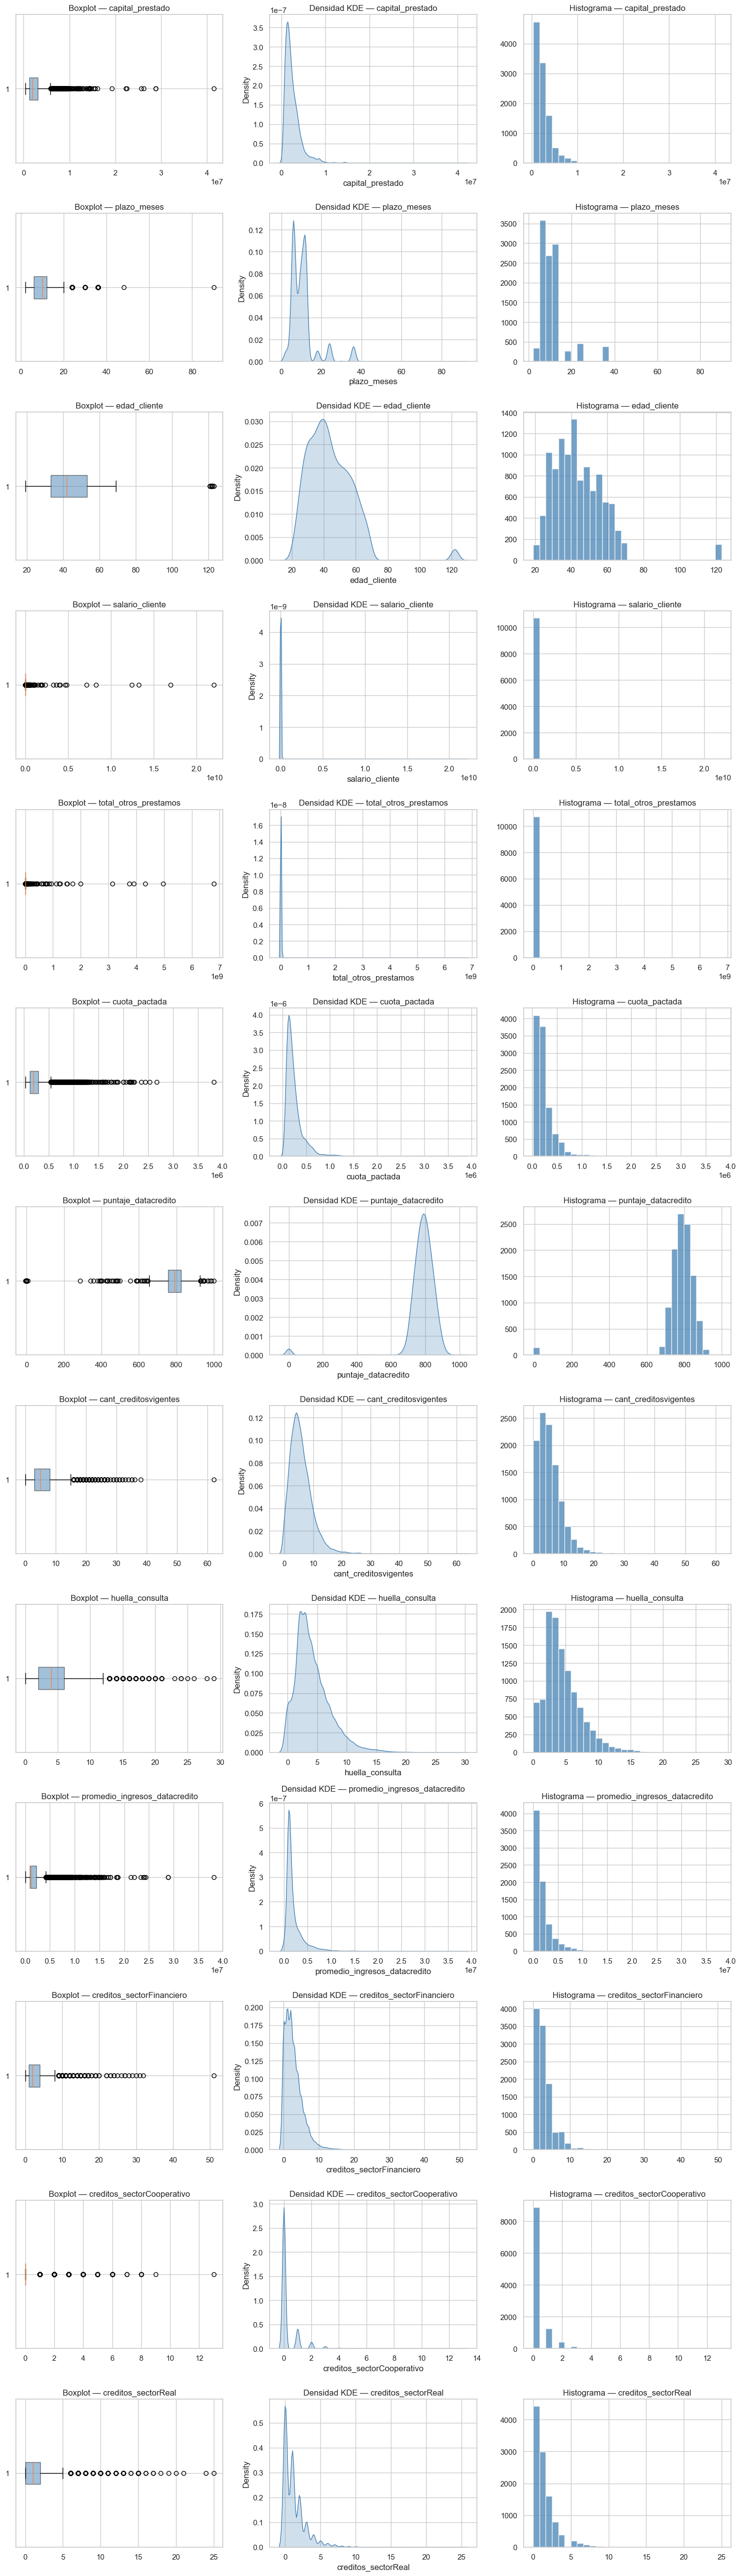

In [120]:
# Variables numericas
num_cols = [
    "capital_prestado", "plazo_meses", "edad_cliente", "salario_cliente",
    "total_otros_prestamos", "cuota_pactada", "puntaje_datacredito",
    "cant_creditosvigentes", "huella_consulta", "promedio_ingresos_datacredito",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo",
    "creditos_sectorReal"
]

fig, axes = plt.subplots(nrows=len(num_cols), ncols=3,
                         figsize=(15, 4 * len(num_cols)))

for i, col in enumerate(num_cols):
    datos = df[col].dropna()

    # Boxplot
    axes[i, 0].boxplot(datos, vert=False, patch_artist=True,
                       boxprops=dict(facecolor="steelblue", alpha=0.5))
    axes[i, 0].set_title(f"Boxplot — {col}")

    # KDE
    sns.kdeplot(datos, fill=True, ax=axes[i, 1], color="steelblue")
    axes[i, 1].set_title(f"Densidad KDE — {col}")

    # Histograma
    axes[i, 2].hist(datos, bins=30, edgecolor="white", color="steelblue", alpha=0.75)
    axes[i, 2].set_title(f"Histograma — {col}")

plt.tight_layout()
plt.show()

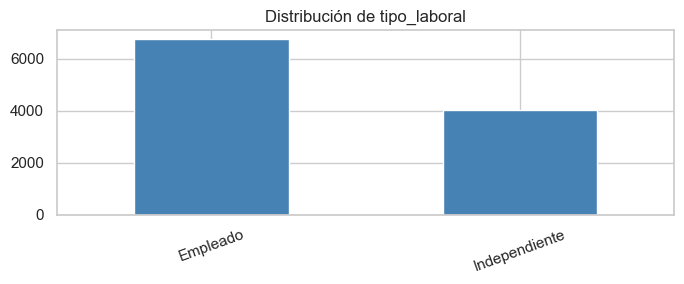

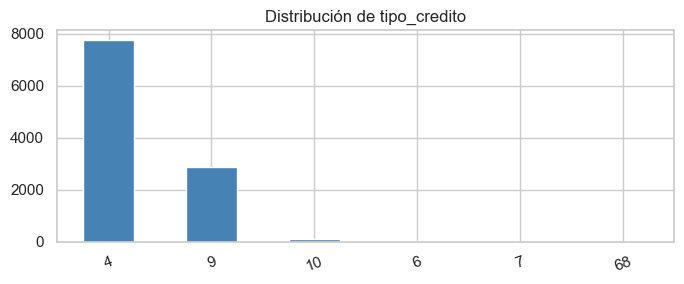

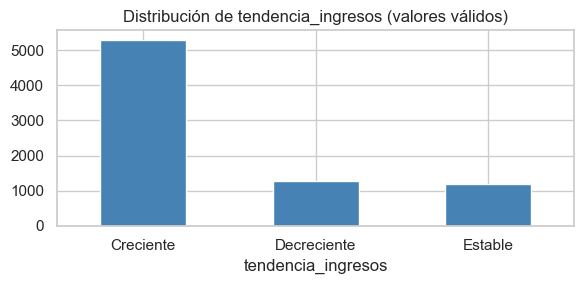

In [121]:
# Variables categóricas
cat_cols_plot = ["tipo_laboral", "tipo_credito"]

for col in cat_cols_plot:
    fig, ax = plt.subplots(figsize=(7, 3))
    df[col].value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
    ax.set_title(f"Distribución de {col}")
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    plt.tight_layout()
    plt.show()

# tendencia_ingresos (solo valores válidos)
valid_ti = df["tendencia_ingresos"].where(df["tendencia_ingresos"].isin({"Creciente","Estable","Decreciente"}))
fig, ax = plt.subplots(figsize=(6, 3))
valid_ti.value_counts().plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_title("Distribución de tendencia_ingresos (valores válidos)")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

---

### **Detección de Outliers (IQR)** 

In [122]:
outlier_summary = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    lim_inf, lim_sup = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((s < lim_inf) | (s > lim_sup)).sum()
    outlier_summary.append({
        "Variable": col,
        "Q1": round(q1, 2),
        "Q3": round(q3, 2),
        "Lím. inf (IQR)": round(lim_inf, 2),
        "Lím. sup (IQR)": round(lim_sup, 2),
        "N outliers": n_out,
        "% outliers": round(n_out / len(df) * 100, 2)
    })

out_df = pd.DataFrame(outlier_summary).sort_values("% outliers", ascending=False)
display(out_df)

,Variable,Q1,Q3,Lím. inf (IQR),Lím. sup (IQR),N outliers,% outliers
11,creditos_sectorCooperativo,0.0000,0.0000,0.0000,0.0000,1895,17.6100
1,plazo_meses,6.0000,12.0000,-3.0000,21.0000,869,8.0700
9,promedio_ingresos_datacredito,"925,157.0000","2,231,859.0000","-1,034,896.0000","4,191,912.0000",784,7.2800
5,cuota_pactada,"121,041.5000","287,833.5000","-129,146.5000","538,021.5000",765,7.1100
3,salario_cliente,"2,000,000.0000","4,875,808.0000","-2,313,712.0000","9,189,520.0000",718,6.6700
4,total_otros_prestamos,"500,000.0000","2,000,000.0000","-1,750,000.0000","4,250,000.0000",589,5.4700
0,capital_prestado,"1,224,831.0000","3,084,840.0000","-1,565,182.5000","5,874,853.5000",550,5.1100
10,creditos_sectorFinanciero,1.0000,4.0000,-3.5000,8.5000,364,3.3800
12,creditos_sectorReal,0.0000,2.0000,-3.0000,5.0000,350,3.2500
7,cant_creditosvigentes,3.0000,8.0000,-4.5000,15.5000,242,2.2500


---

### **Análisis Bivariado**

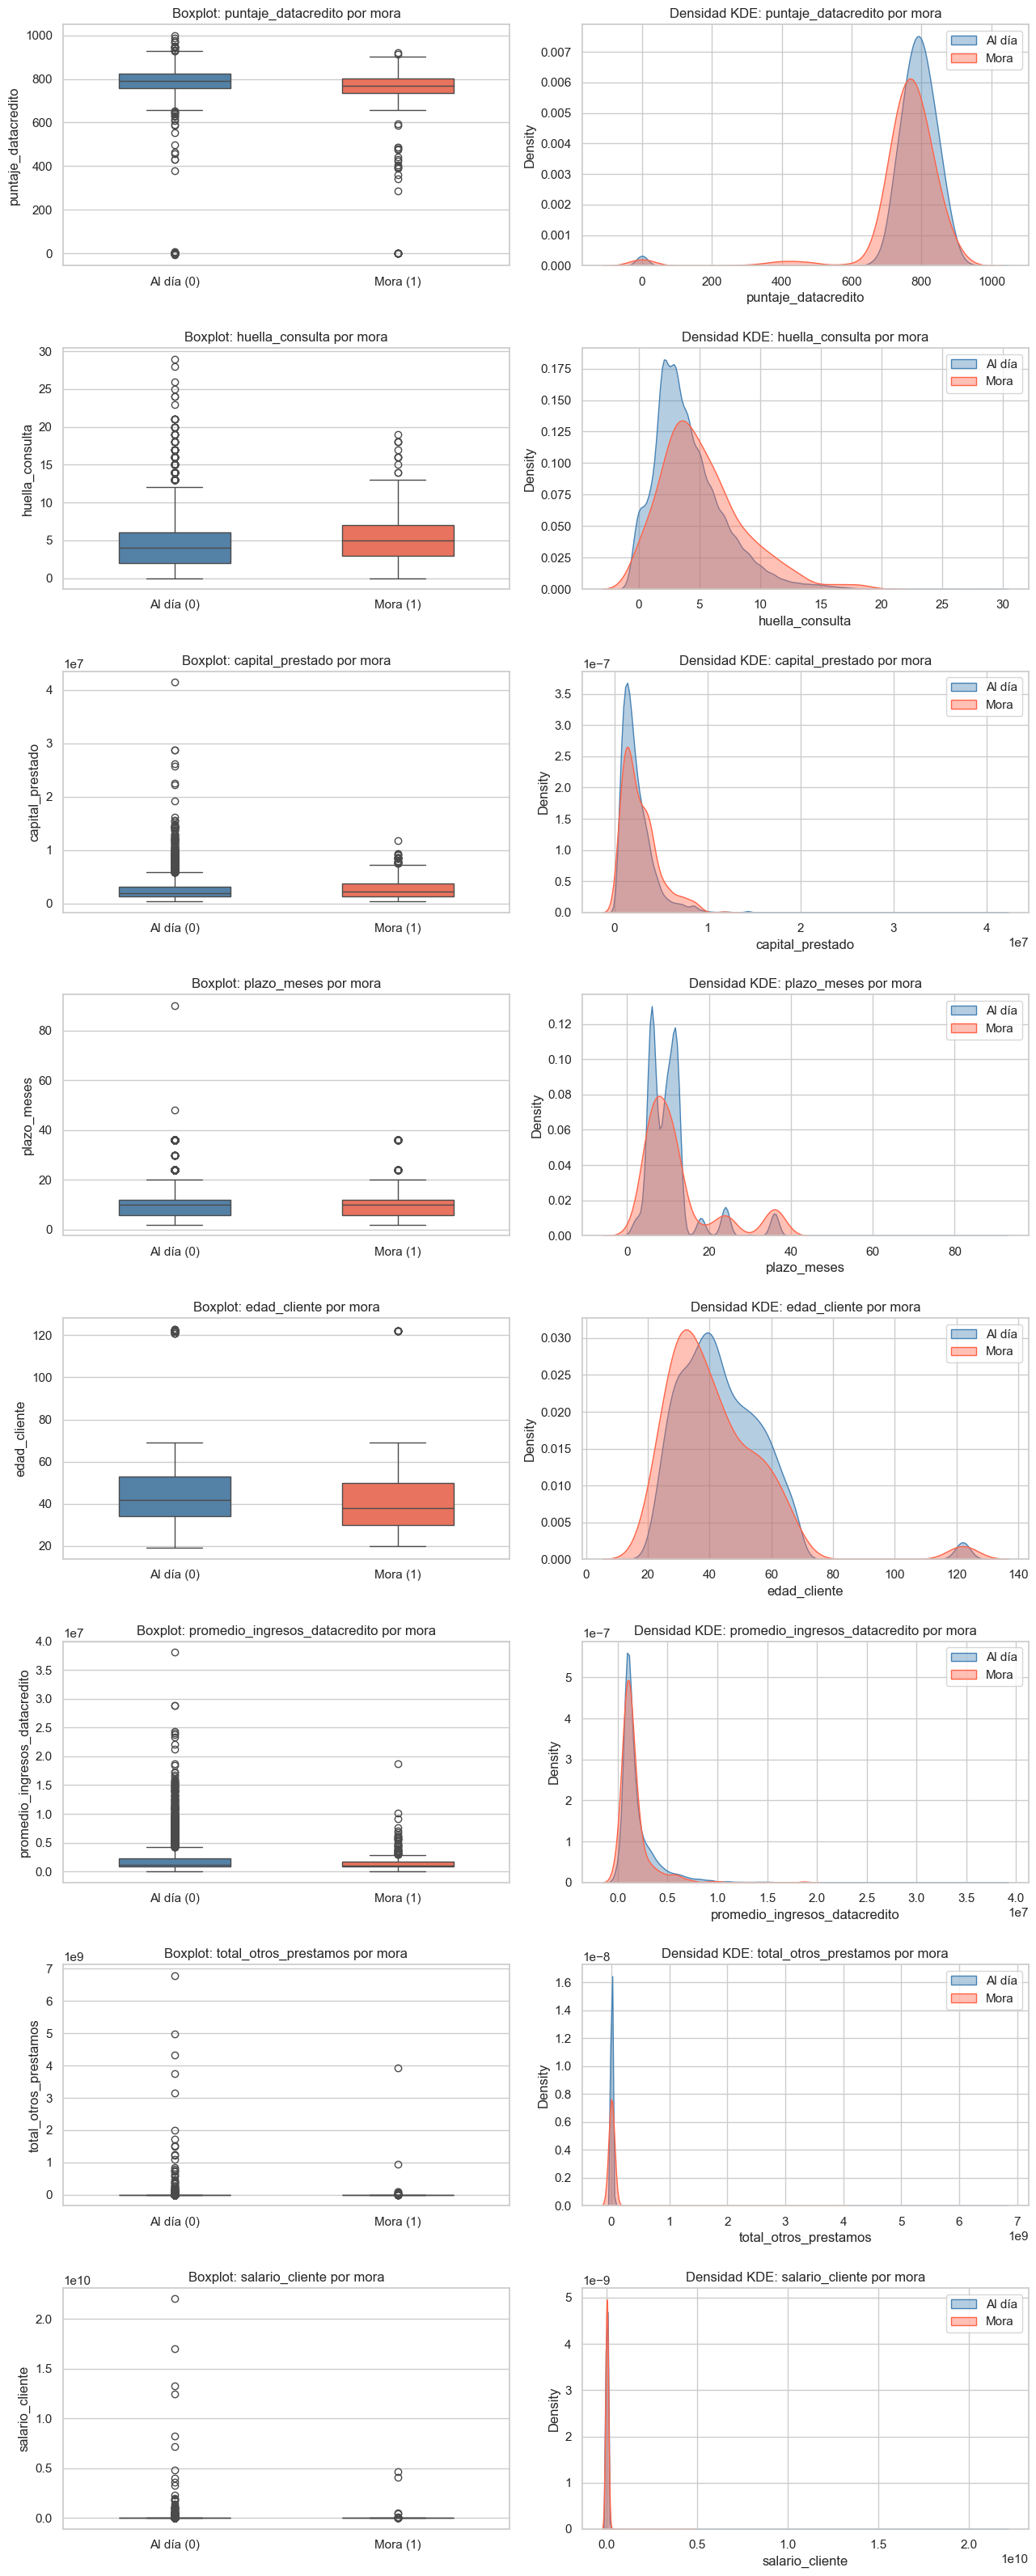

In [133]:
# Numéricas vs mora: Boxplot + KDE por grupo
feat_cols = [
    "puntaje_datacredito", "huella_consulta", "capital_prestado",
    "plazo_meses", "edad_cliente", "promedio_ingresos_datacredito",
    "total_otros_prestamos", "salario_cliente"
]

palette = {0: "steelblue", 1: "tomato"}
labels  = {0: "Al día", 1: "Mora"}

fig, axes = plt.subplots(nrows=len(feat_cols), ncols=2,
                         figsize=(13, 4 * len(feat_cols)))

for i, col in enumerate(feat_cols):
    # Boxplot por grupo — hue= requerido en seaborn >= 0.13
    sns.boxplot(x="mora", y=col, data=df, hue="mora",
                palette=palette, width=0.5, legend=False, ax=axes[i, 0])
    axes[i, 0].set_xticks([0, 1])
    axes[i, 0].set_xticklabels(["Al día (0)", "Mora (1)"])
    axes[i, 0].set_title(f"Boxplot: {col} por mora")
    axes[i, 0].set_xlabel("")

    # KDE superpuesto por grupo
    for cls in [0, 1]:
        subset = df[df["mora"] == cls][col].dropna()
        sns.kdeplot(subset, fill=True, alpha=0.4,
                    color=palette[cls], label=labels[cls], ax=axes[i, 1])
    axes[i, 1].set_title(f"Densidad KDE: {col} por mora")
    axes[i, 1].legend()

plt.tight_layout()
plt.show()

=== tipo_laboral ===


mora,0,1,All
tipo_laboral,,,
Empleado,6464,290,6754
Independiente,3788,221,4009
All,10252,511,10763


,tipo_laboral,mora_rate (%)
1,Independiente,5.5100
0,Empleado,4.2900


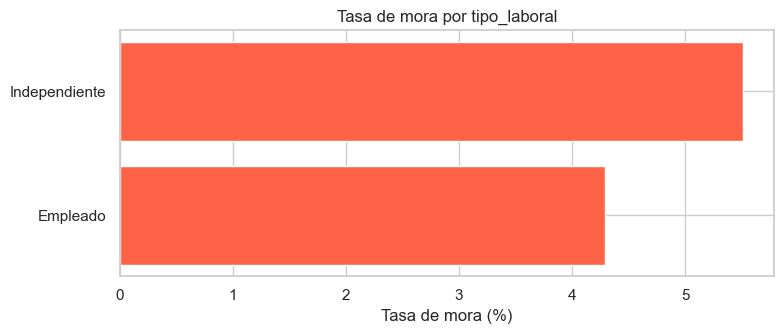

=== tipo_credito ===


mora,0,1,All
tipo_credito,,,
4,7384,363,7747
6,12,9,21
7,2,0,2
9,2740,136,2876
10,113,3,116
68,1,0,1
All,10252,511,10763


,tipo_credito,mora_rate (%)
1,6,42.8600
3,9,4.7300
0,4,4.6900
4,10,2.5900
2,7,0.0000
5,68,0.0000


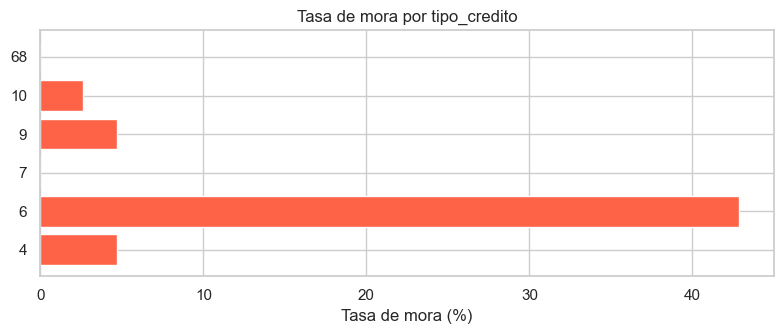

In [124]:
# Categóricas vs mora: crosstab + tasa de mora
cat_features = ["tipo_laboral", "tipo_credito"]

for col in cat_features:
    ct = pd.crosstab(df[col], df["mora"], margins=True)

    mora_rate = (
        df.groupby(col, observed=True)["mora"]
          .mean()
          .mul(100)
          .round(2)
          .rename("mora_rate (%)")
          .reset_index()
    )

    print(f"=== {col} ===")
    display(ct.style.background_gradient(cmap="coolwarm"))
    display(mora_rate.sort_values("mora_rate (%)", ascending=False))

    fig, ax = plt.subplots(figsize=(8, 3.5))
    ax.barh(mora_rate[col].astype(str),
            mora_rate["mora_rate (%)"], color="tomato", edgecolor="white")
    ax.set_xlabel("Tasa de mora (%)")
    ax.set_title(f"Tasa de mora por {col}")
    plt.tight_layout()
    plt.show()

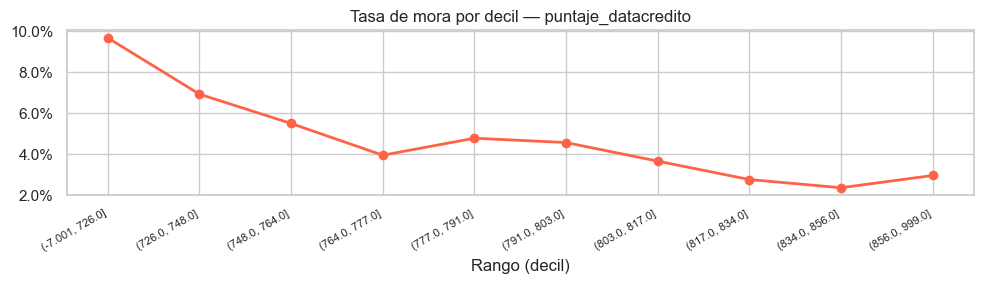

,bin,mora_rate,n
0,"(-7.001, 726.0]",0.0967,1106
1,"(726.0, 748.0]",0.0693,1097
2,"(748.0, 764.0]",0.0550,1073
3,"(764.0, 777.0]",0.0395,1038
4,"(777.0, 791.0]",0.0478,1130
5,"(791.0, 803.0]",0.0457,1029
6,"(803.0, 817.0]",0.0366,1093
7,"(817.0, 834.0]",0.0276,1086
8,"(834.0, 856.0]",0.0236,1058
9,"(856.0, 999.0]",0.0296,1047


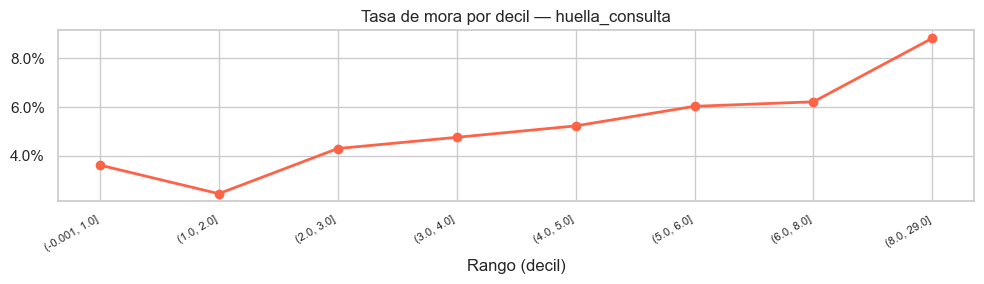

,bin,mora_rate,n
0,"(-0.001, 1.0]",0.0361,1441
1,"(1.0, 2.0]",0.0243,1974
2,"(2.0, 3.0]",0.0429,1888
3,"(3.0, 4.0]",0.0475,1452
4,"(4.0, 5.0]",0.0522,1149
5,"(5.0, 6.0]",0.0603,846
6,"(6.0, 8.0]",0.0621,1062
7,"(8.0, 29.0]",0.0883,951


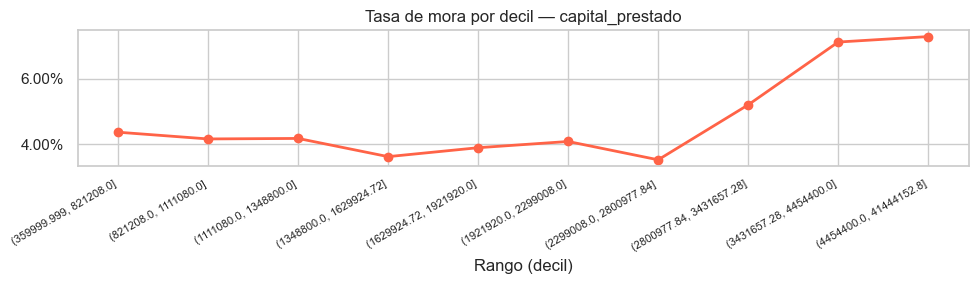

,bin,mora_rate,n
0,"(359999.999, 821208.0]",0.0437,1098
1,"(821208.0, 1111080.0]",0.0417,1056
2,"(1111080.0, 1348800.0]",0.0418,1076
3,"(1348800.0, 1629924.72]",0.0363,1075
4,"(1629924.72, 1921920.0]",0.0390,1077
5,"(1921920.0, 2299008.0]",0.0409,1076
6,"(2299008.0, 2800977.84]",0.0353,1076
7,"(2800977.84, 3431657.28]",0.0520,1076
8,"(3431657.28, 4454400.0]",0.0712,1082
9,"(4454400.0, 41444152.8]",0.0728,1071


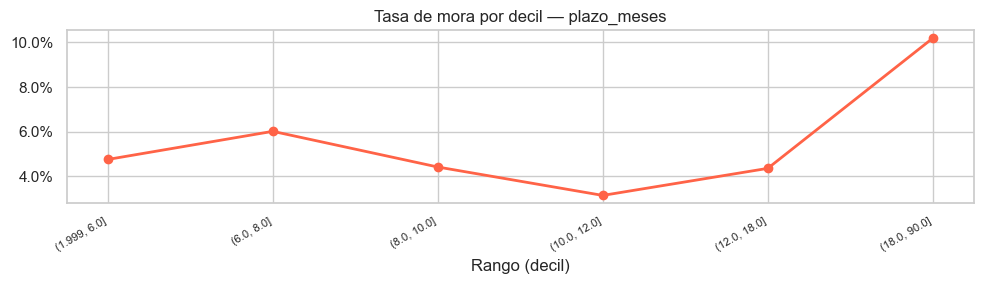

,bin,mora_rate,n
0,"(1.999, 6.0]",0.0476,3905
1,"(6.0, 8.0]",0.0602,548
2,"(8.0, 10.0]",0.0442,2170
3,"(10.0, 12.0]",0.0315,2982
4,"(12.0, 18.0]",0.0436,275
5,"(18.0, 90.0]",0.1019,883


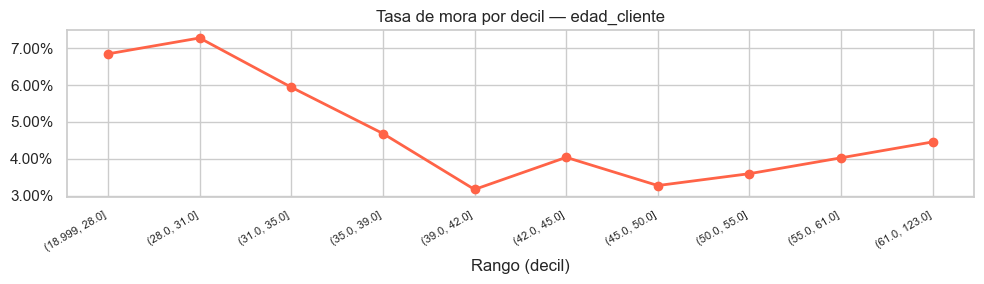

,bin,mora_rate,n
0,"(18.999, 28.0]",0.0685,1299
1,"(28.0, 31.0]",0.0728,865
2,"(31.0, 35.0]",0.0594,1127
3,"(35.0, 39.0]",0.0469,1323
4,"(39.0, 42.0]",0.0317,1011
5,"(42.0, 45.0]",0.0404,842
6,"(45.0, 50.0]",0.0327,1131
7,"(50.0, 55.0]",0.0359,1085
8,"(55.0, 61.0]",0.0403,1093
9,"(61.0, 123.0]",0.0446,987


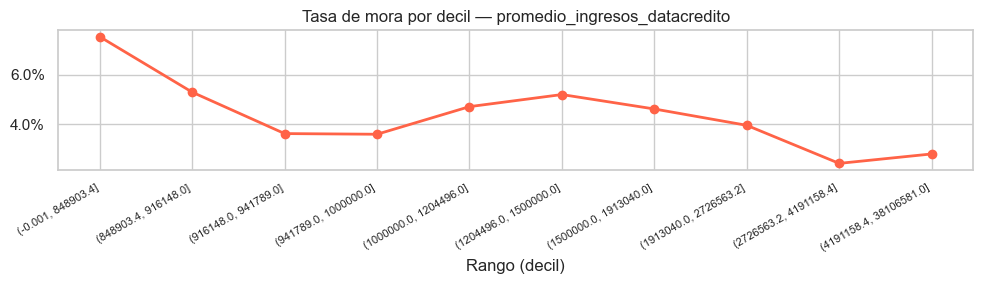

,bin,mora_rate,n
0,"(-0.001, 848903.4]",0.0753,784
1,"(848903.4, 916148.0]",0.0529,869
2,"(916148.0, 941789.0]",0.0363,717
3,"(941789.0, 1000000.0]",0.0360,889
4,"(1000000.0, 1204496.0]",0.0471,658
5,"(1204496.0, 1500000.0]",0.0520,808
6,"(1500000.0, 1913040.0]",0.0462,758
7,"(1913040.0, 2726563.2]",0.0396,783
8,"(2726563.2, 4191158.4]",0.0243,783
9,"(4191158.4, 38106581.0]",0.0281,784


In [125]:
# Tasa de mora por decil (variables numéricas clave)
def default_rate_by_bin(df_in: pd.DataFrame, col: str, q: int = 10) -> pd.DataFrame:
    tmp = df_in[[col, "mora"]].dropna().copy()
    tmp["bin"] = pd.qcut(tmp[col], q=q, duplicates="drop")
    return (
        tmp.groupby("bin", observed=True)["mora"]
           .agg(["mean", "size"])
           .rename(columns={"mean": "mora_rate", "size": "n"})
           .reset_index()
    )

decil_cols = ["puntaje_datacredito", "huella_consulta", "capital_prestado",
              "plazo_meses", "edad_cliente", "promedio_ingresos_datacredito"]

for col in decil_cols:
    rate = default_rate_by_bin(df, col)
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.plot(range(len(rate)), rate["mora_rate"] * 100,
            marker="o", color="tomato", linewidth=2)
    ax.set_xticks(range(len(rate)))
    ax.set_xticklabels([str(b) for b in rate["bin"]], rotation=30, ha="right", fontsize=8)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.set_title(f"Tasa de mora por decil — {col}")
    ax.set_xlabel("Rango (decil)")
    plt.tight_layout()
    plt.show()
    display(rate)

---

### **Matriz de Correlación**

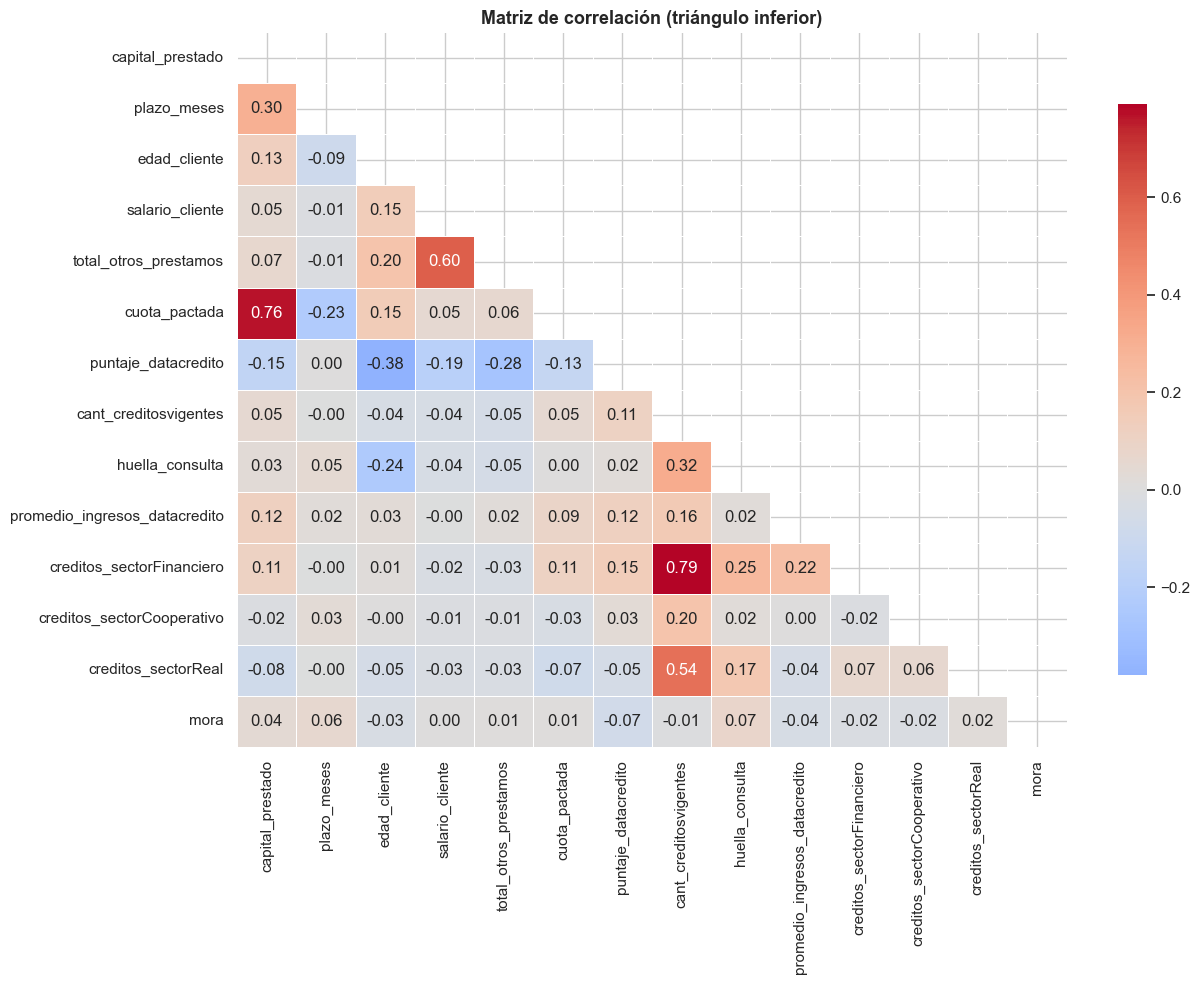

Correlación con mora (excluye leakage):


,corr(mora)
huella_consulta,0.0737
puntaje_datacredito,-0.0679
plazo_meses,0.0631
capital_prestado,0.0406
promedio_ingresos_datacredito,-0.0399
edad_cliente,-0.0323
creditos_sectorReal,0.0233
creditos_sectorFinanciero,-0.0214
creditos_sectorCooperativo,-0.0213
cuota_pactada,0.0118


In [126]:
corr_cols = num_cols + ["mora"]
corr_matrix = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.5,
    cbar_kws={"shrink": 0.8}, ax=ax
)
ax.set_title("Matriz de correlación (triángulo inferior)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

# Top correlaciones con mora
print("Correlación con mora (excluye leakage):")
display(
    corr_matrix["mora"].drop("mora")
      .sort_values(key=abs, ascending=False)
      .rename("corr(mora)")
      .to_frame()
)

---

### **Scatter Matrix**

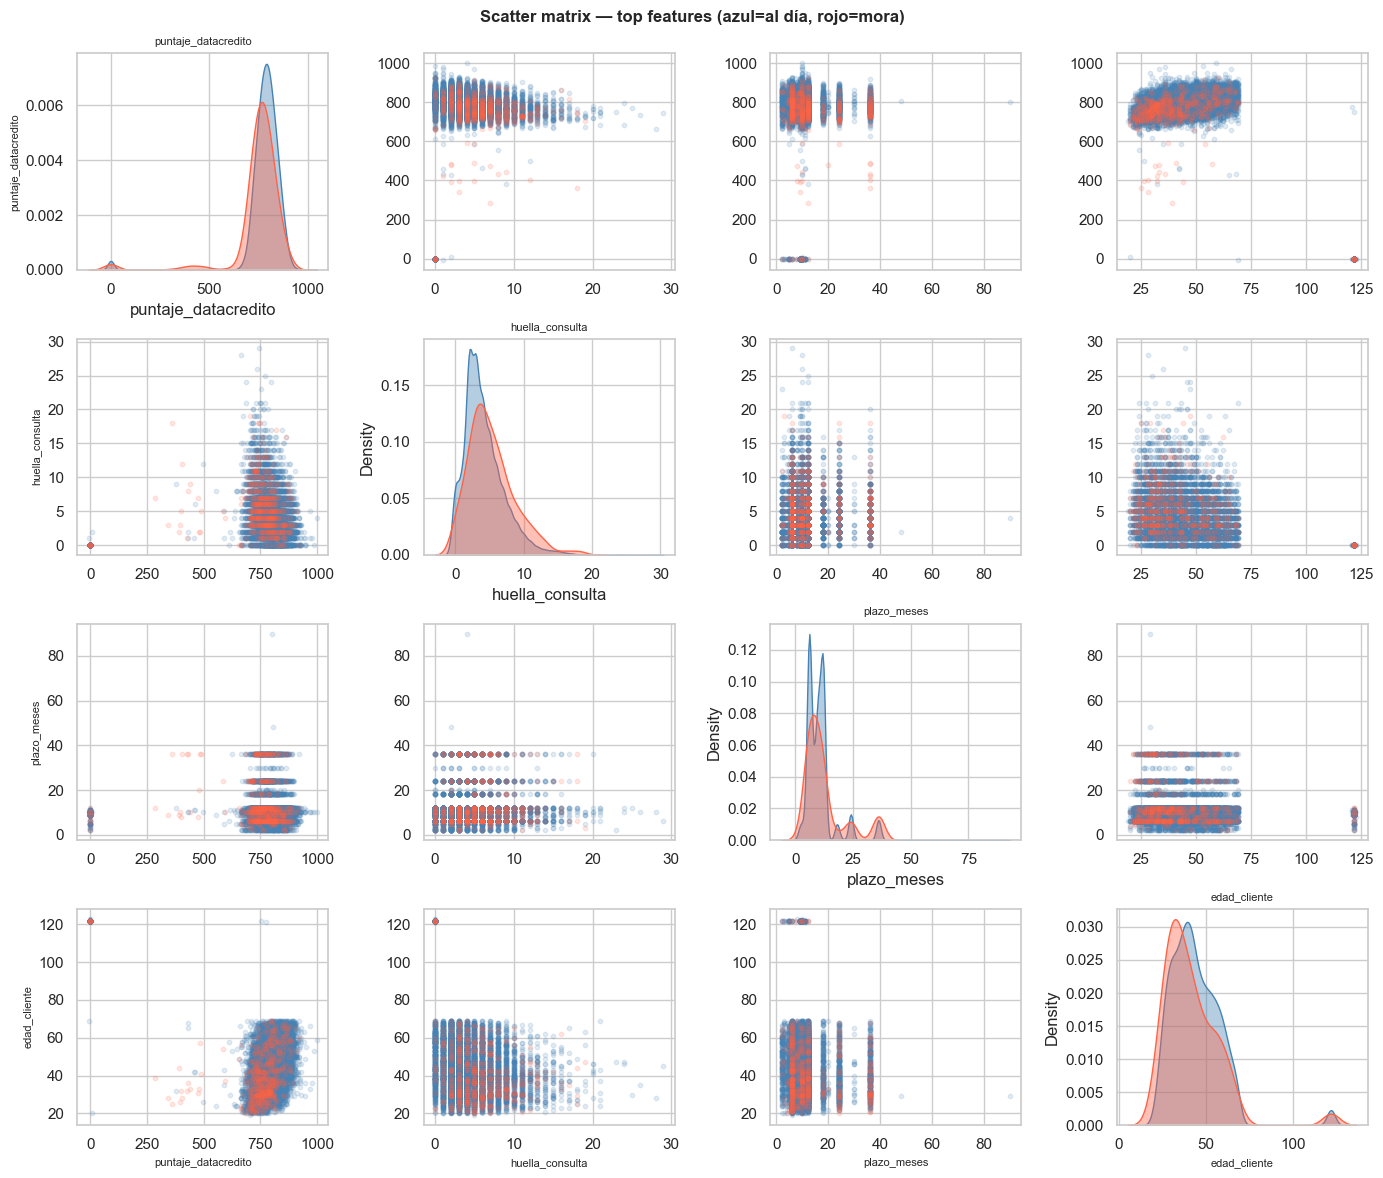

In [127]:
top_feats = ["puntaje_datacredito", "huella_consulta", "plazo_meses", "edad_cliente", "mora"]

scatter_df = df[top_feats].copy()
scatter_df["mora"] = scatter_df["mora"].astype(str)

fig, axes = plt.subplots(len(top_feats)-1, len(top_feats)-1,
                         figsize=(14, 12))

feat_no_target = [c for c in top_feats if c != "mora"]

for i, col1 in enumerate(feat_no_target):
    for j, col2 in enumerate(feat_no_target):
        ax = axes[i][j]
        if i == j:
            for cls, color in [("0", "steelblue"), ("1", "tomato")]:
                subset = df[df["mora"].astype(str) == cls][col1].dropna()
                sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.4)
            ax.set_title(col1, fontsize=8)
        else:
            for cls, color in [("0", "steelblue"), ("1", "tomato")]:
                subset = df[df["mora"].astype(str) == cls]
                ax.scatter(subset[col2], subset[col1],
                           alpha=0.15, s=10, color=color)
        if j == 0:
            ax.set_ylabel(col1, fontsize=8)
        if i == len(feat_no_target)-1:
            ax.set_xlabel(col2, fontsize=8)

plt.suptitle("Scatter matrix — top features (azul=al día, rojo=mora)",
             fontsize=12, fontweight="bold")
plt.tight_layout()
plt.show()

---

### **Pruebas Estadísticas**

In [128]:
# T-test de Student — Variables numéricas vs mora
# Contrasta si la media de cada variable numérica difiere significativamente
# entre clientes en mora y al día. H₀: las medias son iguales.
from scipy import stats

ttest_results = []
for col in num_cols:
    g0 = df[df["mora"] == 0][col].dropna()
    g1 = df[df["mora"] == 1][col].dropna()
    t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)  # Welch
    ttest_results.append({
        "Variable": col,
        "Media al día": round(g0.mean(), 2),
        "Media mora": round(g1.mean(), 2),
        "t-stat": round(t_stat, 3),
        "p-valor": round(p_val, 5),
        "Significancia": "***" if p_val < 0.001 else "**" if p_val < 0.01
                         else "*" if p_val < 0.05 else "ns"
    })

ttest_df = pd.DataFrame(ttest_results).sort_values("p-valor")
display(ttest_df)

print("Leyenda: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo")

,Variable,Media al día,Media mora,t-stat,p-valor,Significancia
1,plazo_meses,10.4800,12.4500,-4.7400,0.0000,***
6,puntaje_datacredito,782.3800,748.8800,5.6910,0.0000,***
8,huella_consulta,4.1800,5.2400,-6.8300,0.0000,***
9,promedio_ingresos_datacredito,"2,023,447.7700","1,605,742.0500",4.4670,0.0000,***
0,capital_prestado,"2,416,996.2700","2,781,774.1100",-4.1470,0.0000,***
2,edad_cliente,44.0600,41.7700,2.9700,0.0031,**
11,creditos_sectorCooperativo,0.2700,0.2000,2.5270,0.0118,*
10,creditos_sectorFinanciero,2.7900,2.5200,2.3020,0.0217,*
12,creditos_sectorReal,1.2900,1.4900,-2.1580,0.0314,*
5,cuota_pactada,"243,062.2300","254,755.6900",-1.2760,0.2024,ns


Leyenda: *** p<0.001 | ** p<0.01 | * p<0.05 | ns = no significativo


In [129]:
# Chi-cuadrado — Variables categóricas vs mora
cat_stat_cols = ["tipo_laboral", "tipo_credito"]

chi2_results = []
for col in cat_stat_cols:
    ct = pd.crosstab(df[col], df["mora"])
    chi2_stat, p_val, dof, _ = stats.chi2_contingency(ct)
    chi2_results.append({
        "Variable": col,
        "Chi2": round(chi2_stat, 4),
        "p-valor": round(p_val, 5),
        "Grados de libertad": dof,
        "Significancia": "***" if p_val < 0.001 else "**" if p_val < 0.01
                         else "*" if p_val < 0.05 else "ns"
    })

display(pd.DataFrame(chi2_results))

,Variable,Chi2,p-valor,Grados de libertad,Significancia
0,tipo_laboral,7.9968,0.0047,1,**
1,tipo_credito,68.8567,0.0000,5,***


,Variable,IV,Poder predictivo
0,puntaje_datacredito,0.1994,Medio
1,huella_consulta,0.1455,Medio
3,plazo_meses,0.1278,Medio
5,promedio_ingresos_datacredito,0.1069,Medio
4,edad_cliente,0.0889,Débil
2,capital_prestado,0.0745,Débil
7,total_otros_prestamos,0.0539,Débil
8,cant_creditosvigentes,0.0264,Débil
6,salario_cliente,0.0240,Débil
9,creditos_sectorFinanciero,0.0227,Débil


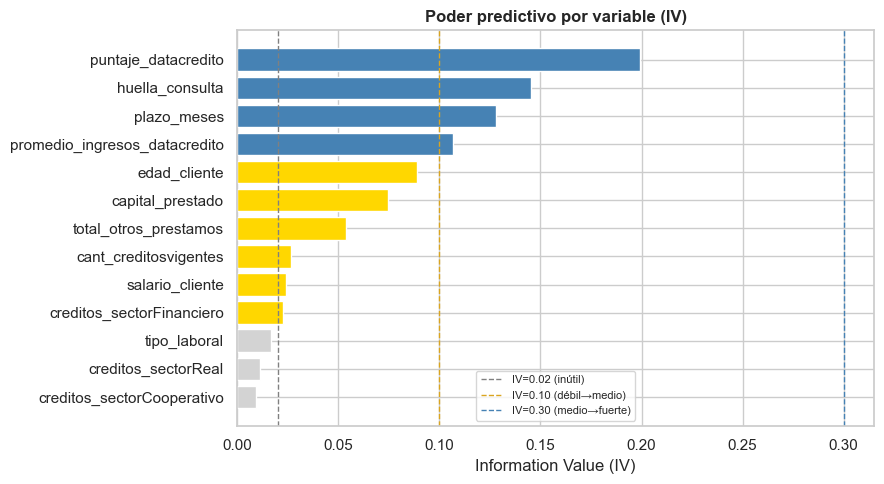

In [134]:
# Weight of Evidence (WoE) e Information Value (IV)
# Escala de referencia estándar en credit scoring:
#   < 0.02   → Inútil
#   0.02–0.1 → Débil
#   0.1–0.3  → Medio
#   0.3–0.5  → Fuerte
#   > 0.5    → Sospechoso (posible leakage)

def woe_iv(data: pd.DataFrame, feature: str, target: str = "mora",
           bins: int = 10) -> tuple[pd.DataFrame, float]:
    """Calcula WoE e IV para una variable vs el target binario."""
    tmp = data[[feature, target]].dropna().copy()

    # Compatibilidad pandas 2.x: StringDtype no es object pero sí is_string_dtype
    is_cat = isinstance(tmp[feature].dtype, pd.CategoricalDtype)
    if pd.api.types.is_string_dtype(tmp[feature]) or is_cat:
        tmp["bin"] = tmp[feature].astype(str)
    else:
        tmp["bin"] = pd.qcut(tmp[feature], q=bins, duplicates="drop")

    total_ev  = tmp[target].sum()
    total_nev = (tmp[target] == 0).sum()

    g = tmp.groupby("bin", observed=True)[target].agg(["sum", "count"])
    g.columns = ["events", "total"]
    g["non_events"] = g["total"] - g["events"]
    g["dist_ev"]    = g["events"]     / total_ev
    g["dist_nev"]   = g["non_events"] / total_nev
    g["woe"]        = np.log((g["dist_ev"] + 1e-9) / (g["dist_nev"] + 1e-9))
    g["iv_bin"]     = (g["dist_ev"] - g["dist_nev"]) * g["woe"]
    return g, g["iv_bin"].sum()


iv_cols = [
    "puntaje_datacredito", "huella_consulta", "capital_prestado",
    "plazo_meses", "edad_cliente", "promedio_ingresos_datacredito",
    "salario_cliente", "total_otros_prestamos", "cant_creditosvigentes",
    "creditos_sectorFinanciero", "creditos_sectorCooperativo",
    "creditos_sectorReal", "tipo_laboral"
]

iv_summary = []
for col in iv_cols:
    _, iv = woe_iv(df, col)
    power = (
        "Inútil"         if iv < 0.02 else
        "Débil"          if iv < 0.10 else
        "Medio"          if iv < 0.30 else
        "Fuerte"         if iv < 0.50 else
        "⚠️ Sospechoso"
    )
    iv_summary.append({"Variable": col, "IV": round(iv, 4), "Poder predictivo": power})

iv_df = pd.DataFrame(iv_summary).sort_values("IV", ascending=False)
display(iv_df)

# Gráfico coloreado por nivel de poder predictivo
color_map = {
    "Inútil": "lightgray", "Débil": "gold",
    "Medio": "steelblue",  "Fuerte": "seagreen", "⚠️ Sospechoso": "tomato"
}
bar_colors = [color_map.get(p, "steelblue") for p in iv_df["Poder predictivo"][::-1]]

fig, ax = plt.subplots(figsize=(9, 5))
ax.barh(iv_df["Variable"][::-1], iv_df["IV"][::-1], color=bar_colors, edgecolor="white")
ax.axvline(0.02, color="gray",      linestyle="--", linewidth=1, label="IV=0.02 (inútil)")
ax.axvline(0.10, color="goldenrod", linestyle="--", linewidth=1, label="IV=0.10 (débil→medio)")
ax.axvline(0.30, color="steelblue", linestyle="--", linewidth=1, label="IV=0.30 (medio→fuerte)")
ax.set_xlabel("Information Value (IV)")
ax.set_title("Poder predictivo por variable (IV)", fontweight="bold")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---

## **Conclusiones**

---

### Dataset
- **10.763 registros**, **23 variables**, **sin duplicados**.
- Tasa global de mora: **4.75%** (511 mora vs 10.252 al día).  
  Dataset fuertemente desbalanceado → considerar **SMOTE**, `class_weight="balanced"` o ajuste del umbral de decisión.

---

### Variables a EXCLUIR (leakage)

| Variable | Razón |
|---|---|
| `saldo_mora` | Refleja el evento directamente, no lo predice |
| `saldo_total` | Calculado post-desembolso, no disponible en el momento de la decisión |
| `saldo_principal` | Calculado post-desembolso |
| `saldo_mora_codeudor` | Refleja el estado post-evento del codeudor |
| `puntaje` | Score calculado **después** de conocer la mora: clientes al día tienen valor máximo fijo (95.23), clientes en mora valores bajos — **leakage confirmado por histograma** |

---

### Variables a EXCLUIR (redundancia)

| Variable | Razón |
|---|---|
| `salario_cliente` | Mide conceptualmente una dimensión muy similar a `promedio_ingresos_datacredito`, pero esta última presenta mayor poder predictivo (IV = 0.107 vs 0.024; p < 0.001 vs p = 0.680). Por parsimonia y para evitar redundancia, se conserva `promedio_ingresos_datacredito` y se excluye `salario_cliente`. |
| `creditos_sectorFinanciero` | Hace parte del número total de créditos vigentes; su información ya está contenida en `cant_creditosvigentes`. Además, su poder predictivo individual es bajo. |
| `creditos_sectorCooperativo` | Variable desagregada que representa una parte del total de créditos vigentes. Presenta IV muy bajo y aporta información redundante respecto a `cant_creditosvigentes`. |
| `creditos_sectorReal` | También corresponde a una descomposición del total de créditos vigentes. Su aporte individual es bajo y genera solapamiento con `cant_creditosvigentes`. |

---

### Variables a LIMPIAR

| Variable | Problema detectado | Acción en `ft_engineering.py` |
|---|---|---|
| `tendencia_ingresos` | 58 registros con valores numéricos en lugar de `"Creciente"`, `"Estable"`, `"Decreciente"` | Reemplazar no válidos por `NaN`, imputar por **moda** |
| `promedio_ingresos_datacredito` | 2.930 nulos (27.2%) | Imputar por **mediana segmentada** por `tipo_laboral` |
| `puntaje_datacredito` | 6 nulos (<0.1%) | Imputar por **mediana global** |
| `salario_cliente` | Outliers IQR: 6.7% fuera de rango | **Winsorización** al percentil 99 |
| `capital_prestado` | Outliers IQR: 5.1% fuera de rango | **Winsorización** al percentil 99 |
| `total_otros_prestamos` | Outliers IQR moderados | **Winsorización** al percentil 99 |

---

### Variables con PODER PREDICTIVO (candidatas al modelo)

| Variable | IV | p-valor (t-test) | Observación |
|---|---|---|---|
| `puntaje_datacredito` | 0.199 *(Medio)* | <0.001 *** | Mayor score → menor mora. Media: 782 (al día) vs 749 (mora) |
| `huella_consulta` | 0.146 *(Medio)* | <0.001 *** | Más consultas en buró → mayor mora. Media: 4.2 vs 5.2 |
| `plazo_meses` | 0.128 *(Medio)* | <0.001 *** | Plazos más largos → mayor riesgo. Media: 10.5 vs 12.5 meses |
| `promedio_ingresos_datacredito` | 0.107 *(Medio)* | <0.001 *** | Menores ingresos históricos → mayor mora |
| `edad_cliente` | 0.089 *(Débil-Medio)* | <0.001 *** | Clientes más jóvenes tienen ligeramente mayor mora. Media: 44.1 vs 41.8 años |
| `capital_prestado` | 0.075 *(Débil)* | <0.001 *** | Mayor monto prestado → mayor mora. Media: $2.4M vs $2.8M |
| `total_otros_prestamos` | 0.054 *(Débil)* | 0.298 *(ns)* | IV moderado pero diferencia de medias no significativa — usar con cautela |
| `tipo_laboral` | — | 0.005 ** | Independientes presentan mayor tasa de mora que empleados |

---

### Variables de BAJO poder predictivo (considerar exclusión)

| Variable | IV | p-valor | Observación |
|---|---|---|---|
| `salario_cliente` | 0.024 *(Débil)* | 0.680 *(ns)* | Alta varianza, no discrimina entre grupos |
| `cant_creditosvigentes` | 0.026 *(Débil)* | 0.360 *(ns)* | No significativo |
| `creditos_sectorCooperativo` | 0.009 *(Inútil)* | 0.027 * | IV por debajo del umbral útil |
| `creditos_sectorReal` | 0.011 *(Inútil)* | 0.016 * | IV por debajo del umbral útil |

---

### Análisis Temporal

- Dataset cubre **noviembre 2024 – abril 2026**; pico de volumen en **enero 2025** (1.917 créditos).
- Mora más alta: **noviembre 2024 (6.99%)**. Mora más baja: **octubre 2025 (1.73%)**.
- Meses de 2026 muestran tasas elevadas: probable efecto de **maduración** — créditos recientes aún no han tenido tiempo suficiente para normalizar su comportamiento.
- ⚠️ **Split train/test debe ser temporal** (no aleatorio): entrenar hasta una fecha de corte y evaluar en meses posteriores para simular producción real.

---

### Decisiones para `ft_engineering.py`

```python
# ── EXCLUIR (leakage) ────────────────────────────────────────────────
DROP_LEAKAGE = [
    "saldo_mora", "saldo_total", "saldo_principal",
    "saldo_mora_codeudor", "puntaje", "Pago_atiempo"
]

# ── EXCLUIR (redundancia / solapamiento) ─────────────────────────────
DROP_REDUNDANT = [
    "salario_cliente",
    "creditos_sectorFinanciero",
    "creditos_sectorCooperativo",
    "creditos_sectorReal"
]

# ── IMPUTAR ──────────────────────────────────────────────────────────
IMPUTE_MEDIAN       = ["puntaje_datacredito"]
IMPUTE_MEDIAN_GROUP = ["promedio_ingresos_datacredito"]  # agrupar por tipo_laboral
IMPUTE_MODE         = ["tendencia_ingresos"]              # solo valores categóricos válidos

# ── WINSORIZAR (cap p99) ─────────────────────────────────────────────
WINSORIZE_COLS = ["salario_cliente", "capital_prestado", "total_otros_prestamos"]

# ── SPLIT TEMPORAL (NO aleatorio) ────────────────────────────────────
TRAIN_CUTOFF = "2025-09"  # entrenar hasta sep-2025, evaluar desde oct-2025
```

---